# 02 — Modelling & Structure Detection

Blueprint for Modules 2 & 3. Input: `{region}_feature_table.csv` from `01_preprocessing.ipynb`.
Output: `{region}_buildings.csv` (structure candidates with confidence, area, and an RF
built-up probability) — the input Module 4 (fusion) depends on.

In [1]:
from concurrent.futures import ThreadPoolExecutor

import ee
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, PrecisionRecallDisplay, accuracy_score
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt

ee.Initialize(project='riparian-encroachment')

REGIONS = ['Kasarani', 'Gatharaini', 'Motoine']
DATA_DIR = '../data/processed'
FEATURE_COLS = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDBI']

CASE_STUDY_RADIUS_KM = 3
REGION_CENTERS = {
    'Kasarani': (36.8969, -1.2296),
    'Gatharaini': (36.95952127354356, -1.2252700532171976),
    'Motoine': (36.74237847877641, -1.3113205815273903),
}

## Step 1 — Train the Random Forest baseline

Trained once on all three regions combined, not per-region — Module 1's boundary-parameterized
design means one classifier should generalize across river reaches instead of needing a
retrain per place. Labels are ESA WorldCover ground truth (already in the feature table),
not a threshold guess.

In [2]:
tables = []
for region in REGIONS:
    df = pd.read_csv(f'{DATA_DIR}/{region.lower()}_feature_table.csv')
    df['region'] = region
    tables.append(df)
combined = pd.concat(tables, ignore_index=True)
print('Combined training table:', combined.shape)

X = combined[FEATURE_COLS]
y = combined['builtup']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
print(classification_report(y_test, preds, target_names=['not built-up', 'built-up']))

joblib.dump(rf, f'{DATA_DIR}/rf_baseline.joblib')

Combined training table: (4800, 12)
              precision    recall  f1-score   support

not built-up       0.86      0.82      0.84       480
    built-up       0.83      0.86      0.84       480

    accuracy                           0.84       960
   macro avg       0.84      0.84      0.84       960
weighted avg       0.84      0.84      0.84       960



['../data/processed/rf_baseline.joblib']

In [3]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[392  88]
 [ 65 415]]


In [4]:
train_preds = rf.predict(X_train)
train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, preds)

print(f"Train accuracy: {train_acc:.2%}")
print(f"Test accuracy:  {test_acc:.2%}")
print(f"Gap:            {(train_acc - test_acc):.2%}")

Train accuracy: 100.00%
Test accuracy:  84.06%
Gap:            15.94%


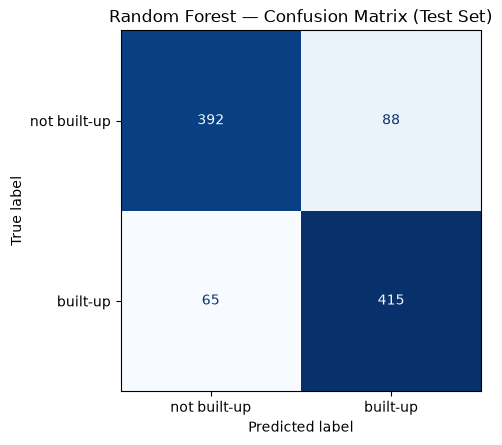

In [5]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['not built-up', 'built-up'],
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('Random Forest — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/rf_confusion_matrix.png', dpi=150)
plt.show()

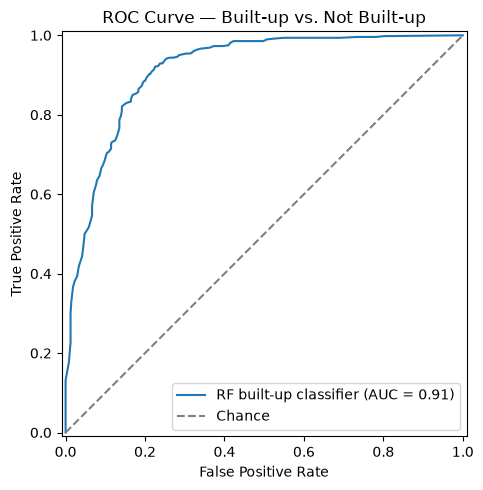

AUC: 0.914


In [8]:
# ROC Curve
y_proba = rf.predict_proba(X_test)[:, 1]  # probability of "built-up"
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name='RF built-up classifier').plot(ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve — Built-up vs. Not Built-up')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/rf_roc_curve.png', dpi=150)
plt.show()

print(f"AUC: {roc_auc:.3f}")

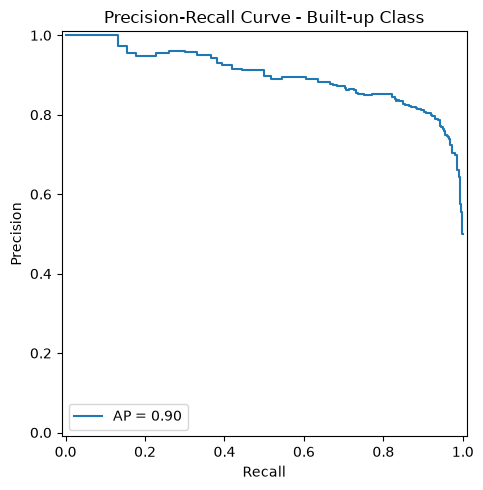

Average precision: 0.900


In [10]:
# Precision-Recall curve
# when false negatives (missed structures) are the costly error
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=avg_precision).plot(ax=ax)
ax.set_title('Precision-Recall Curve - Built-up Class')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/rf_precision_recall_curve.png', dpi=150)
plt.show()

print(f"Average precision: {avg_precision:.3f}")

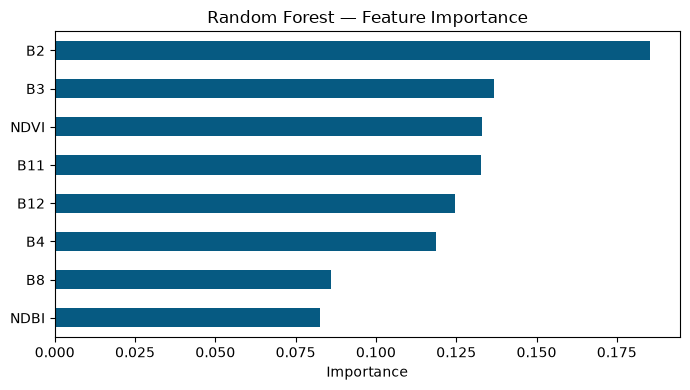

B2      0.185402
B3      0.136695
NDVI    0.133142
B11     0.132617
B12     0.124740
B4      0.118818
B8      0.086021
NDBI    0.082566
dtype: float64


In [11]:
# Feature importance — which bands the model actually relies on
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='#065A82')
ax.invert_yaxis()
ax.set_title('Random Forest — Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/rf_feature_importance.png', dpi=150)
plt.show()

print(importances)


In [12]:
# Cross-validation — is the train/test gap a fluke of one split, or consistent across the data?
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f"5-fold CV accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.2%}  (+/- {cv_scores.std():.2%})")

5-fold CV accuracy scores: [0.81354167 0.84166667 0.83854167 0.86666667 0.846875  ]
Mean CV accuracy: 84.15%  (+/- 1.70%)


In [13]:
# Threshold sensitivity - how the built-up cutoff (default 0.5) trades recall against precision, relevant to how permissive

for t in [0.05, 0.1, 0.2, 0.3, 0.5, 0.7]:
    preds_at_t = (y_proba >= t).astype(int)
    tp = ((preds_at_t == 1) & (y_test == 1)).sum()
    fn = ((preds_at_t == 0) & (y_test == 1)).sum()
    fp = ((preds_at_t == 1) & (y_test == 0)).sum()
    recall_t = tp / (tp + fn) if (tp + fn) else 0
    precision_t = tp / (tp + fp) if (tp + fp) else 0
    print(f"threshold={t:.2f}  recall={recall_t:.2%}  precision={precision_t:.2%}")



threshold=0.05  recall=99.38%  precision=58.96%
threshold=0.10  recall=99.17%  precision=65.38%
threshold=0.20  recall=97.29%  precision=71.63%
threshold=0.30  recall=95.00%  precision=76.90%
threshold=0.50  recall=86.88%  precision=82.25%
threshold=0.70  recall=71.46%  precision=86.18%


## Step 2 — Resolution check: is a custom detector (e.g. YOLO) even viable here?

Decided by measurement, not assumption: compare the imagery's pixel size against the actual
building size in this data — median Open Buildings footprint area, converted to an effective
diameter via `sqrt(area)` — not an assumed number.

In [ ]:
SENTINEL_PIXEL_SIZE_M = 10  # native Sentinel-2 resolution for the bands used above


def get_open_buildings_sample(aoi_ee, confidence_threshold=0.7, limit=2000):
    buildings = (
        ee.FeatureCollection('GOOGLE/Research/open-buildings/v3/polygons')
        .filterBounds(aoi_ee)
        .filter(ee.Filter.gte('confidence', confidence_threshold))
        .limit(limit)
    )
    return buildings.getInfo()['features']


kasarani_aoi_ee = ee.Geometry.Point(list(REGION_CENTERS['Kasarani'])).buffer(CASE_STUDY_RADIUS_KM * 1000)
sample_features = get_open_buildings_sample(kasarani_aoi_ee)
areas = [f['properties']['area_in_meters'] for f in sample_features]
median_area = pd.Series(areas).median()
effective_building_size_m = median_area ** 0.5

print(f'Median Open Buildings footprint area (Kasarani sample): {median_area:.1f} m^2')
print(f'Effective building size (sqrt of area): {effective_building_size_m:.1f} m')
print(f'Sentinel-2 pixel size: {SENTINEL_PIXEL_SIZE_M} m')
print(f'Custom detector viable on this imagery: {effective_building_size_m > SENTINEL_PIXEL_SIZE_M}')

Median Open Buildings footprint area (Kasarani sample): 64.9 m^2
Effective building size (sqrt of area): 8.1 m
Sentinel-2 pixel size: 10 m
Custom detector viable on this imagery: False


## Step 3 — Swappable structure detector

Both strategies share one interface, `detect_structures(aoi_ee, resolution_m) -> DataFrame`,
so picking a branch never means deleting the other's code.

**Strategy B (default on Sentinel-2): Google Open Buildings** — works at native resolution,
no imagery upgrade required. Keep `confidence` and `area_in_meters`, not just a bare centroid,
so downstream steps can filter on confidence and flag unusually large/small footprints.

Batches are fetched concurrently (`ThreadPoolExecutor` — the network wait, not local CPU, is
what's slow) rather than one at a time: Kasarani alone has ~57,000 candidate buildings, and
fetching those sequentially takes well over 15 minutes.

In [ ]:
def detect_structures_open_buildings(aoi_ee, confidence_threshold=0.7, batch_size=4000, max_workers=6):
    fc = (
        ee.FeatureCollection('GOOGLE/Research/open-buildings/v3/polygons')
        .filterBounds(aoi_ee)
        .filter(ee.Filter.gte('confidence', confidence_threshold))
    )
    n = fc.size().getInfo()
    print(f'  {n} candidates, fetching in batches of {batch_size}')

    def fetch_batch(start):
        return ee.FeatureCollection(fc.toList(batch_size, start)).getInfo()['features']

    starts = list(range(0, n, batch_size))
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        batches = pool.map(fetch_batch, starts)

    rows = []
    for batch in batches:
        for f in batch:
            props = f['properties']
            lon, lat = props['longitude_latitude']['coordinates']
            rows.append({
                'lon': lon,
                'lat': lat,
                'confidence': props['confidence'],
                'area_m2': props['area_in_meters'],
            })
    return pd.DataFrame(rows)


def detect_structures_yolo(aoi_ee, resolution_m):
    """Strategy A — placeholder behind the same interface. Not implemented: needs imagery finer
    than the building size it must resolve, and Step 2 above measures whether that's even
    available yet. Wire this up once such imagery exists; Module 4 doesn't care which strategy
    produced its input, only that the output columns match."""
    raise NotImplementedError(
        'Needs imagery finer than the building size it must resolve — see Step 2.'
    )


def detect_structures(aoi_ee, resolution_m=SENTINEL_PIXEL_SIZE_M, building_size_m=effective_building_size_m):
    if resolution_m < building_size_m:
        return detect_structures_yolo(aoi_ee, resolution_m)
    return detect_structures_open_buildings(aoi_ee)

## Step 4 — Score every building with the RF built-up signal

For each detected building, sample the same spectral/NDVI/NDBI bands used to train the RF at
the building's own centroid (`Image.sampleRegions` — one batched Earth Engine call, not one
call per building) and run them through the trained model.

In [ ]:
def get_feature_image(aoi_ee, start_date='2024-01-01', end_date='2024-12-31'):
    s2 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi_ee).filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    )
    composite = s2.select(FEATURE_COLS[:6]).median().clip(aoi_ee)
    ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndbi = composite.normalizedDifference(['B11', 'B8']).rename('NDBI')
    return composite.addBands(ndvi).addBands(ndbi)


def score_buildings(buildings_df, aoi_ee, rf_model, batch_size=4000, max_workers=6):
    feature_image = get_feature_image(aoi_ee)

    def sample_batch(start):
        chunk = buildings_df.iloc[start:start + batch_size]
        points_fc = ee.FeatureCollection([
            ee.Feature(ee.Geometry.Point([row.lon, row.lat]), {'row_id': i})
            for i, row in chunk.iterrows()
        ])
        sampled = feature_image.sampleRegions(collection=points_fc, scale=10, geometries=False).getInfo()['features']
        return pd.DataFrame([
            {'row_id': f['properties']['row_id'], **{c: f['properties'].get(c) for c in FEATURE_COLS}}
            for f in sampled
        ]).set_index('row_id')

    starts = list(range(0, len(buildings_df), batch_size))
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        scored_frames = list(pool.map(sample_batch, starts))
    sampled_all = pd.concat(scored_frames)
    merged = buildings_df.join(sampled_all, how='left')
    valid = merged.dropna(subset=FEATURE_COLS)
    merged.loc[valid.index, 'rf_builtup_prob'] = rf_model.predict_proba(valid[FEATURE_COLS])[:, 1]
    return merged

## Step 5 — Run for all three regions, save outputs

Screen buildings within the same fixed-radius circle Module 1 uses for each region (matching
`REGION_CENTERS`/`CASE_STUDY_RADIUS_KM` above) — not the whole city, and not a separately
hand-picked bounding box, for the same reason Module 1 avoided one.

In [ ]:
model_summary = {}
for region in REGIONS:
    print(f'--- {region} ---')
    aoi_ee = ee.Geometry.Point(list(REGION_CENTERS[region])).buffer(CASE_STUDY_RADIUS_KM * 1000)
    buildings_df = detect_structures(aoi_ee)
    scored = score_buildings(buildings_df, aoi_ee, rf)
    out_path = f'{DATA_DIR}/{region.lower()}_buildings.csv'
    scored.to_csv(out_path, index=False)
    model_summary[region] = {
        'buildings_detected': len(scored),
        'buildings_scored': int(scored['rf_builtup_prob'].notna().sum()),
    }
    print(model_summary[region])

pd.DataFrame(model_summary).T

--- Kasarani ---
  56678 candidates, fetching in batches of 4000
{'buildings_detected': 56678, 'buildings_scored': 56585}
--- Gatharaini ---
  27123 candidates, fetching in batches of 4000
{'buildings_detected': 27123, 'buildings_scored': 27080}
--- Motoine ---
  28554 candidates, fetching in batches of 4000
{'buildings_detected': 28554, 'buildings_scored': 28488}


,buildings_detected,buildings_scored
Kasarani,56678,56585
Gatharaini,27123,27080
Motoine,28554,28488
